# Tile Price Prediction — Model Training

This notebook trains an XGBoost model on the features engineered in `01_EDA.ipynb`. We use a 5-fold cross validation strategy to get an honest estimate of model performance.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import shap
import matplotlib.pyplot as plt

train_df = pd.read_pickle('../outputs/train_processed.pkl')
test_df = pd.read_pickle('../outputs/test_processed.pkl')

print(f'Train: {train_df.shape}, Test: {test_df.shape}')

Train: (2272, 113), Test: (568, 111)


## 1. Prepare Feature Matrix

In [2]:
# Features to include in the model
numeric_features = [
    'tile_volume_mm3', 'tile_area_mm2', 'aspect_ratio',
    'product_width_val', 'product_length_val', 'product_thickness_val',
    'pieces_per_box_num', 'boxes_per_pallet_num', 'area_per_box_val',
    'box_weight_val', 'area_per_pallet_val', 'loaded_pallet_weight_val',
    'breaking_strength_val', 'modulus_of_rupture_val', 'water_absorption_rate_val',
    'mohs_surface_hardness_val', 'dcof_value', 'pei_value',
    'r_rating_val', 'pendulum_val', 'barefoot_val',
    'is_glazed_int',
    'collection_mean_price', 'collection_std_price', 'collection_count', 'collection_mean_log_price',
    'pei_value_is_missing', 'dcof_value_is_missing', 'mohs_surface_hardness_val_is_missing',
    'water_absorption_rate_val_is_missing', 'breaking_strength_val_is_missing',
    'modulus_of_rupture_val_is_missing', 'r_rating_val_is_missing',
    'barefoot_val_is_missing', 'pendulum_val_is_missing'
]

categorical_features = [
    'finish_keyword', 'body_type', 'shade_variation_rating', 'edge_type',
    'finish_type', 'subcategory', 'app_combo', 'piece_type'
]

# Combine train and test for consistent Label Encoding
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)

for col in categorical_features:
    combined[col] = combined[col].astype(str)
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col])

# Split back
X_train_full = combined.iloc[:len(train_df)][numeric_features + categorical_features].copy()
y_train_full = train_df['log_price'].values
y_true_actual = train_df['price_usd_per_sqm'].values

X_test_full = combined.iloc[len(train_df):][numeric_features + categorical_features].copy()

# XGBoost natively handles NaNs, but replacing them with a sentinel value can sometimes help
X_train_full = X_train_full.fillna(-999)
X_test_full = X_test_full.fillna(-999)

print(f'X_train shape: {X_train_full.shape}')

X_train shape: (2272, 43)


## 2. Train XGBoost Model with 5-Fold Cross Validation

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_log = np.zeros(len(X_train_full))
test_preds_log = np.zeros(len(X_test_full))

models = []

xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
    print(f'--- Fold {fold+1} ---')
    X_train_fold, y_train_fold = X_train_full.iloc[train_idx], y_train_full[train_idx]
    X_val_fold, y_val_fold = X_train_full.iloc[val_idx], y_train_full[val_idx]
    
    dtrain = xgb.DMatrix(X_train_fold, label=y_train_fold)
    dval = xgb.DMatrix(X_val_fold, label=y_val_fold)
    dtest = xgb.DMatrix(X_test_full)
    
    model = xgb.train(
        xgb_params,
        dtrain,
        num_boost_round=1000,
        evals=[(dval, 'val')],
        early_stopping_rounds=50,
        verbose_eval=100
    )
    
    models.append(model)
    
    oof_preds_log[val_idx] = model.predict(dval)
    test_preds_log += model.predict(dtest) / kf.n_splits

oof_preds_actual = np.exp(oof_preds_log)

--- Fold 1 ---
[0]	val-rmse:0.29879
[100]	val-rmse:0.03394
[200]	val-rmse:0.02792
[300]	val-rmse:0.02626
[400]	val-rmse:0.02578
[500]	val-rmse:0.02555
[600]	val-rmse:0.02531
[684]	val-rmse:0.02527
--- Fold 2 ---
[0]	val-rmse:0.30201
[100]	val-rmse:0.04298
[200]	val-rmse:0.03489
[300]	val-rmse:0.03252
[400]	val-rmse:0.03144
[500]	val-rmse:0.03072
[542]	val-rmse:0.03079
--- Fold 3 ---
[0]	val-rmse:0.31350
[100]	val-rmse:0.05632
[200]	val-rmse:0.04845
[300]	val-rmse:0.04694
[400]	val-rmse:0.04631
[500]	val-rmse:0.04589
[540]	val-rmse:0.04597
--- Fold 4 ---
[0]	val-rmse:0.29264
[100]	val-rmse:0.04993
[200]	val-rmse:0.04464
[300]	val-rmse:0.04340
[400]	val-rmse:0.04292
[500]	val-rmse:0.04267
[594]	val-rmse:0.04271
--- Fold 5 ---
[0]	val-rmse:0.31152
[100]	val-rmse:0.03063
[200]	val-rmse:0.02093
[300]	val-rmse:0.01807
[400]	val-rmse:0.01705
[500]	val-rmse:0.01655
[600]	val-rmse:0.01628
[700]	val-rmse:0.01610
[800]	val-rmse:0.01599
[900]	val-rmse:0.01592
[999]	val-rmse:0.01586


## 3. Evaluation Metrics

In [4]:
def calculate_metrics(y_true, y_pred_actual, y_pred_log, y_true_log):
    mae = mean_absolute_error(y_true, y_pred_actual)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    
    error_pct = np.abs(y_true - y_pred_actual) / y_true
    within_10_pct = np.mean(error_pct <= 0.10) * 100
    within_20_pct = np.mean(error_pct <= 0.20) * 100
    
    print(f'Mean Absolute Error (Actual $): ${mae:.2f}')
    print(f'RMSE (Log Scale): {rmse_log:.4f}')
    print(f'Within ±10% of True Price: {within_10_pct:.1f}%')
    print(f'Within ±20% of True Price: {within_20_pct:.1f}%')
    
    return mae, rmse_log, within_10_pct, within_20_pct

print('Overall Cross-Validation Performance:')
metrics = calculate_metrics(y_true_actual, oof_preds_actual, oof_preds_log, y_train_full)

Overall Cross-Validation Performance:
Mean Absolute Error (Actual $): $0.11
RMSE (Log Scale): 0.0340
Within ±10% of True Price: 98.5%
Within ±20% of True Price: 99.5%


## 4. Feature Importance (SHAP)

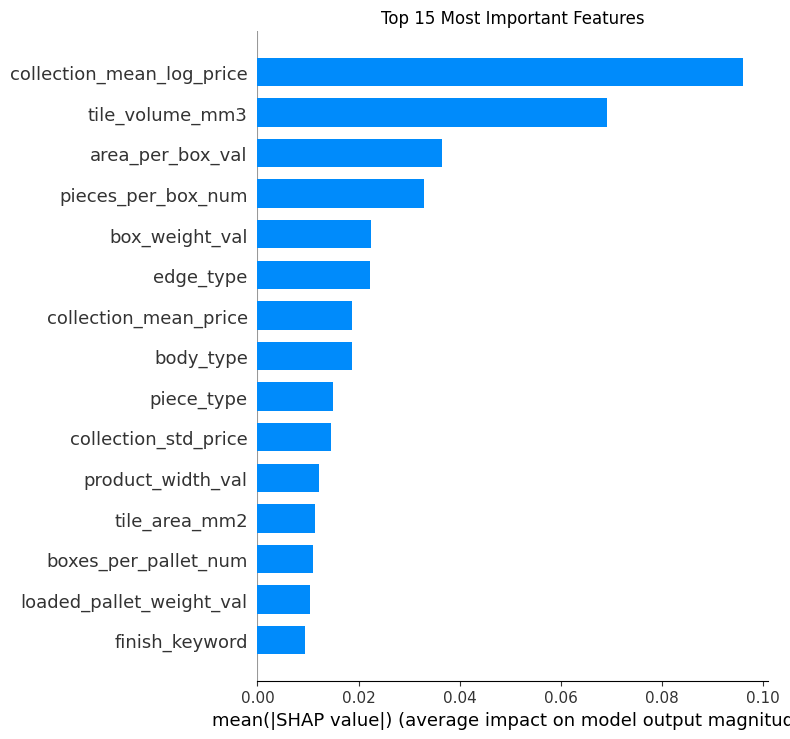

In [6]:
# Explain the last fold's model using XGBoost's native SHAP calculation (bypasses SHAP parsing bug)
dtrain_full = xgb.DMatrix(X_train_full)
shap_values_matrix = models[-1].predict(dtrain_full, pred_contribs=True)
shap_values = shap_values_matrix[:, :-1]  # The last column is the bias term

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_full, plot_type='bar', max_display=15, show=False)
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.savefig('../outputs/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Generate Submission
Use the averaged test predictions from 5-fold CV to create the final submission file.

In [ ]:
# Convert averaged log-predictions back to actual dollar prices
test_preds_actual = np.exp(test_preds_log)

submission = pd.DataFrame({
    'sku_id': test_df['sku_id'].values,
    'price_usd_per_sqm': test_preds_actual
})

print(f'Submission shape: {submission.shape}')
print(f'Price range: ${submission["price_usd_per_sqm"].min():.2f} – ${submission["price_usd_per_sqm"].max():.2f}')
print(f'Mean price: ${submission["price_usd_per_sqm"].mean():.2f}')
print(submission.head())

import os
os.makedirs('../outputs', exist_ok=True)
submission.to_csv('../outputs/submission.csv', index=False)
print(f'\nSaved to outputs/submission.csv  ({len(submission)} rows)')
